# Logit Model — Bootstrap Inference

This notebook extends the logit analysis of stock delisting by applying nonparametric bootstrap to obtain the sampling distribution of:

1. **Coefficients** ($\beta_0$, $\beta_1$)
2. **Average Marginal Effect (AME)**
3. **Marginal Effect at the Mean (MEM)**

We resample with replacement from the estimation sample, re-estimate the logit each time, and collect the quantities of interest.

Suppose we are interested in predicting the probability of delisting of a stock due to either:
- Bankrupt
- Liquidation

as function of its size. 

## 0. Required packages

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm  # optional: progress bar (pip install tqdm)

## 1. Load and prepare data

This section is identical to the original notebook.

In [3]:
df = pd.read_csv("../Chapter3/Delisting.csv", parse_dates=["datadate", "dldte"])

# Keep observations that are before deletion date (or never deleted)
df = df[df["dldte"].isna() | (df["datadate"] < df["dldte"])].copy()

# Clean deletion reason codes to 2-digit strings
df["dlrsn"] = df["dlrsn"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(2)

FAIL_CODES = {"02", "03"}  # bankruptcy, liquidation

days_to_del = (df["dldte"] - df["datadate"]).dt.days
df["FAIL_1Y"] = ((days_to_del >= 1) & (days_to_del <= 365) & (df["dlrsn"].isin(FAIL_CODES))).astype(int)
df["SURV_5Y"] = (df["dldte"].isna() | ((df["dldte"] - df["datadate"]).dt.days > 5 * 365)).astype(int)

df = df[df['atq'] > 0]
df["X"] = np.log(df["atq"])

use_all = df[["FAIL_1Y", "SURV_5Y", "X"]].replace([np.inf, -np.inf], np.nan).dropna()
x_lo, x_hi = use_all["X"].quantile([0.001, 0.999])
use_all = use_all[(use_all["X"] >= x_lo) & (use_all["X"] <= x_hi)].copy()

# Balanced sample
events = use_all[use_all["FAIL_1Y"] == 1]
controls = use_all[(use_all["FAIL_1Y"] == 0) & (use_all["SURV_5Y"] == 1)]

n = len(events)
if n == 0:
    raise ValueError("No failure events found.")
if len(controls) < n:
    controls_s = controls.sample(n=len(controls), random_state=0)
    events_s = events.sample(n=len(controls), random_state=0)
else:
    controls_s = controls.sample(n=n, random_state=0)
    events_s = events

use = pd.concat([events_s, controls_s], axis=0).sample(frac=1, random_state=1)
print(f"Balanced sample: N = {len(use)}, event rate = {use['FAIL_1Y'].mean():.3f}")

Balanced sample: N = 3160, event rate = 0.500


## 2. Point estimates (baseline)

We first estimate the logit once on the full sample to get the point estimates.

In [4]:
y = use["FAIL_1Y"].astype(float)
X = sm.add_constant(use[["X"]])

logit = sm.Logit(y, X).fit(disp=0)

ame = logit.get_margeff(at='overall')
mem = logit.get_margeff(at='mean')

print("=== Logit coefficients ===")
print(logit.summary())
print("\n=== AME ===")
print(ame.summary())
print("\n=== MEM ===")
print(mem.summary())

=== Logit coefficients ===
                           Logit Regression Results                           
Dep. Variable:                FAIL_1Y   No. Observations:                 3160
Model:                          Logit   Df Residuals:                     3158
Method:                           MLE   Df Model:                            1
Date:                Thu, 14 May 2026   Pseudo R-squ.:                 0.05867
Time:                        14:42:40   Log-Likelihood:                -2061.8
converged:                       True   LL-Null:                       -2190.3
Covariance Type:            nonrobust   LLR p-value:                 7.720e-58
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0233      0.077     13.222      0.000       0.872       1.175
X             -0.2243      0.015    -15.065      0.000      -0.253      -0.195

=== AME ===
        Logi

## 3. Bootstrap

We draw $B = 2000$ bootstrap samples (with replacement) from the estimation sample.
For each resample we:
1. Re-estimate the logit
2. Store $\hat{\beta}_0^{(b)}$ and $\hat{\beta}_1^{(b)}$
3. Compute and store the AME and MEM of $X$

Failed convergence iterations are silently skipped.

In [11]:
B = 10000
rng = np.random.default_rng(42)

boot_beta0 = np.full(B, np.nan)
boot_beta1 = np.full(B, np.nan)
boot_ame   = np.full(B, np.nan)
boot_mem   = np.full(B, np.nan)

y_arr = y.values
X_arr = X.values
n_obs = len(y_arr)

for b in tqdm(range(B), desc="Bootstrap"):
    idx = rng.integers(0, n_obs, size=n_obs)
    y_b = y_arr[idx]
    X_b = X_arr[idx]

    # Skip degenerate samples (all 0s or all 1s)
    if y_b.sum() == 0 or y_b.sum() == n_obs:
        continue

    try:
        model_b = sm.Logit(y_b, X_b).fit(disp=0, maxiter=100, warn_convergence=False)

        boot_beta0[b] = model_b.params[0]
        boot_beta1[b] = model_b.params[1]

        # AME: average of individual marginal effects
        ame_b = model_b.get_margeff(at='overall')
        boot_ame[b] = ame_b.margeff[0]

        # MEM: marginal effect evaluated at the sample mean
        mem_b = model_b.get_margeff(at='mean')
        boot_mem[b] = mem_b.margeff[0]

    except Exception:
        continue

# Drop failed iterations
valid = ~np.isnan(boot_beta0)
print(f"\nSuccessful bootstrap replications: {valid.sum()} / {B}")

boot_beta0 = boot_beta0[valid]
boot_beta1 = boot_beta1[valid]
boot_ame   = boot_ame[valid]
boot_mem   = boot_mem[valid]

Bootstrap: 100%|████████████████████████████████████████████████████████████████| 10000/10000 [00:57<00:00, 174.00it/s]


Successful bootstrap replications: 10000 / 10000


## 4. Bootstrap summary statistics

We report the bootstrap mean, standard error (= std of bootstrap distribution), and the 2.5 %–97.5 % percentile confidence interval.

In [21]:
def boot_summary(name, point_est, boot_dist):
    """Print a summary row for one bootstrap quantity."""
    ci_lo, ci_hi = np.percentile(boot_dist, [2.5, 97.5])
    print(f"{name:12s}  point = {point_est:+.5f}   "
          f"boot mean = {boot_dist.mean():+.5f}   "
          f"boot SE = {boot_dist.std():.5f}   "
          f"95% CI = [{ci_lo:+.5f}, {ci_hi:+.5f}]")

print("=" * 100)
boot_summary("beta_0", logit.params.iloc[0], boot_beta0)
boot_summary("beta_1", logit.params.iloc[1], boot_beta1)
boot_summary("AME(X)", ame.margeff[0], boot_ame)
boot_summary("MEM(X)", mem.margeff[0], boot_mem)
print("=" * 100)

beta_0        point = +1.02327   boot mean = +1.02441   boot SE = 0.08707   95% CI = [+0.85975, +1.20197]
beta_1        point = -0.22426   boot mean = -0.22459   boot SE = 0.01589   95% CI = [-0.25657, -0.19430]
AME(X)        point = -0.05168   boot mean = -0.05168   boot SE = 0.00314   95% CI = [-0.05789, -0.04563]
MEM(X)        point = -0.05607   boot mean = -0.05613   boot SE = 0.00397   95% CI = [-0.06413, -0.04856]


## 5. Distribution of bootstrap coefficients

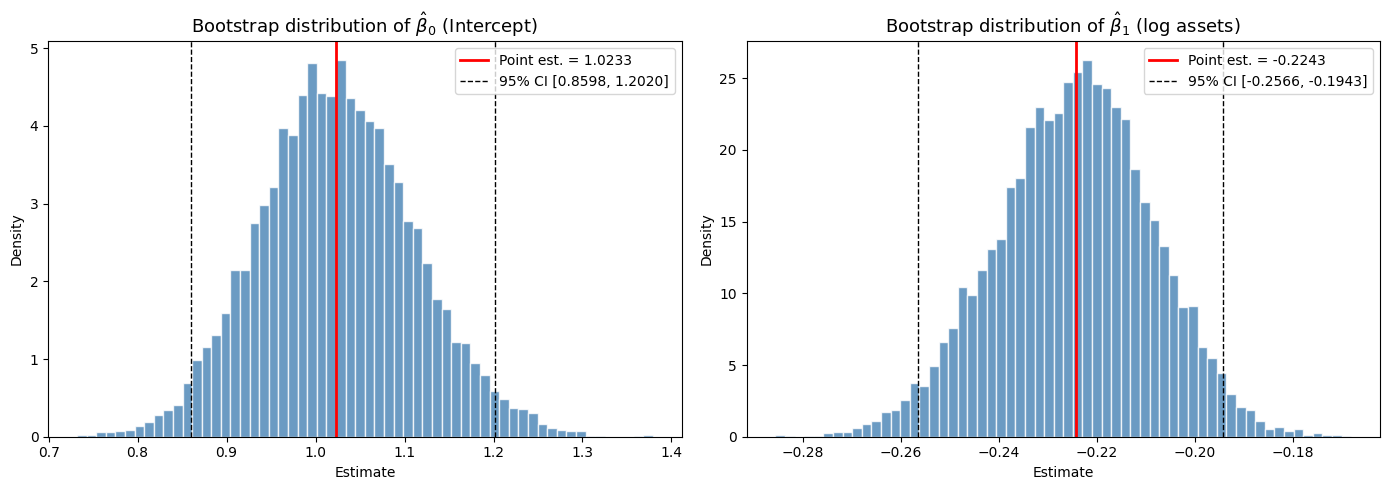

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, name, pt in zip(
    axes,
    [boot_beta0, boot_beta1],
    [r"$\hat{\beta}_0$ (Intercept)", r"$\hat{\beta}_1$ (log assets)"],
    [logit.params.iloc[0], logit.params.iloc[1]],
):
    ax.hist(data, bins=60, density=True, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(pt, color="red", linewidth=2, label=f"Point est. = {pt:.4f}")

    ci = np.percentile(data, [2.5, 97.5])
    ax.axvline(ci[0], color="black", linestyle="--", linewidth=1, label=f"95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
    ax.axvline(ci[1], color="black", linestyle="--", linewidth=1)

    ax.set_title(f"Bootstrap distribution of {name}", fontsize=13)
    ax.set_xlabel("Estimate")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 6. Distribution of AME and MEM

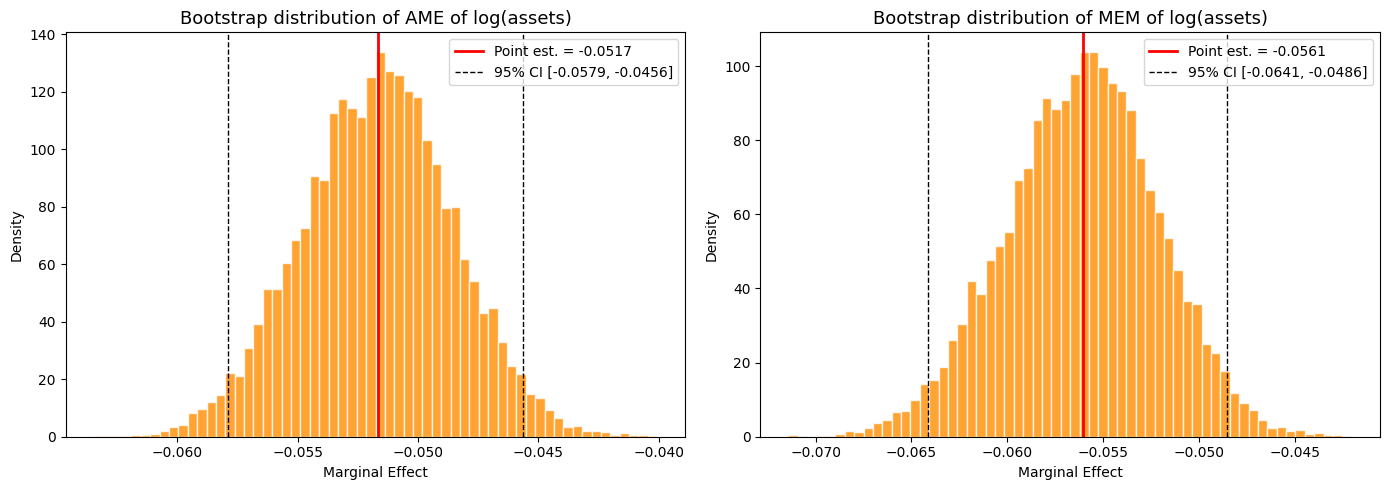

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, name, pt in zip(
    axes,
    [boot_ame, boot_mem],
    ["AME of log(assets)", "MEM of log(assets)"],
    [ame.margeff[0], mem.margeff[0]],
):
    ax.hist(data, bins=60, density=True, color="darkorange", edgecolor="white", alpha=0.8)
    ax.axvline(pt, color="red", linewidth=2, label=f"Point est. = {pt:.4f}")

    ci = np.percentile(data, [2.5, 97.5])
    ax.axvline(ci[0], color="black", linestyle="--", linewidth=1, label=f"95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
    ax.axvline(ci[1], color="black", linestyle="--", linewidth=1)

    ax.set_title(f"Bootstrap distribution of {name}", fontsize=13)
    ax.set_xlabel("Marginal Effect")
    ax.set_ylabel("Density")
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 7. Joint distribution of coefficients

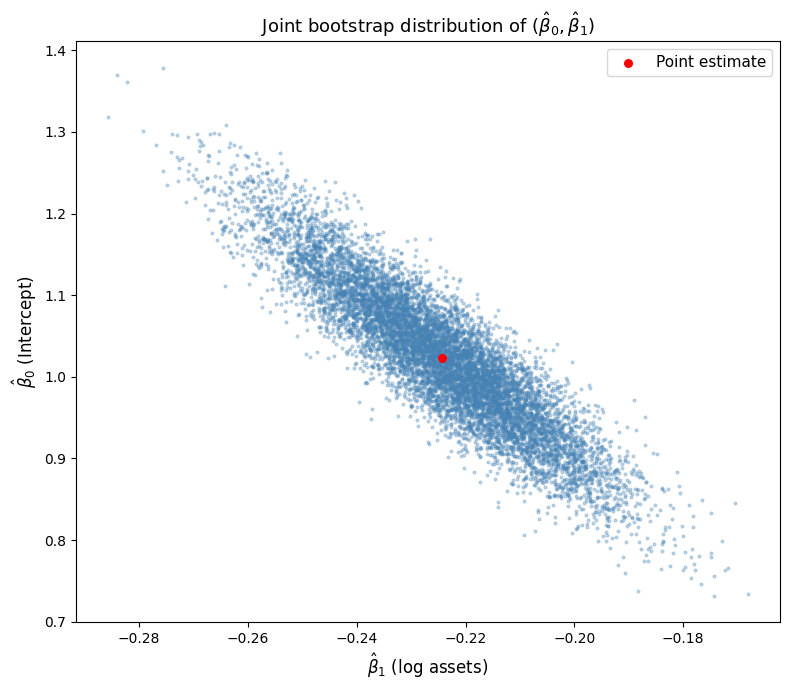

In [23]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(boot_beta1, boot_beta0, s=4, alpha=0.3, color="steelblue")
ax.scatter(logit.params.iloc[1], logit.params.iloc[0], s=120, color="red", marker=".",
           zorder=5, label="Point estimate")

ax.set_xlabel(r"$\hat{\beta}_1$ (log assets)", fontsize=12)
ax.set_ylabel(r"$\hat{\beta}_0$ (Intercept)", fontsize=12)
ax.set_title(r"Joint bootstrap distribution of $(\hat{\beta}_0, \hat{\beta}_1)$", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Comparison: AME vs MEM

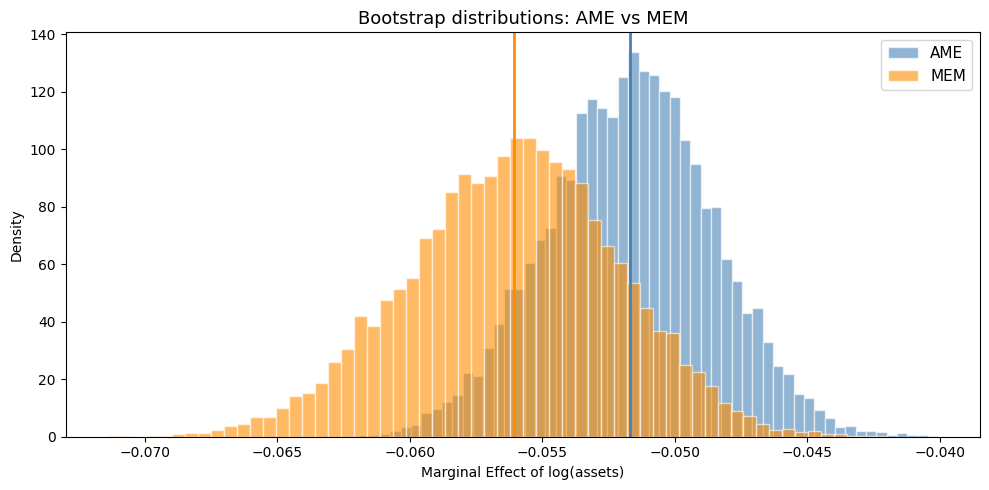

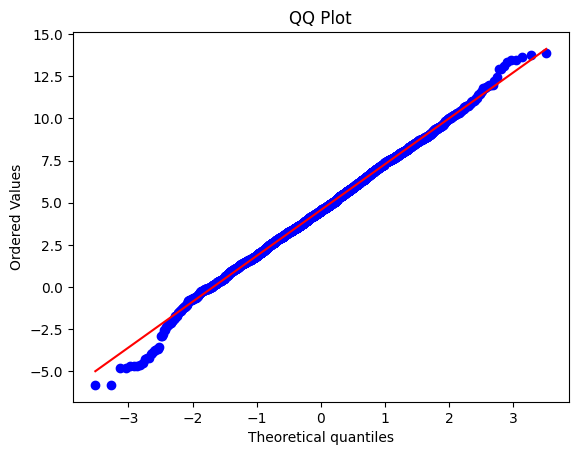

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(boot_ame, bins=60, density=True, color="steelblue", edgecolor="white",
        alpha=0.6, label="AME")
ax.hist(boot_mem, bins=60, density=True, color="darkorange", edgecolor="white",
        alpha=0.6, label="MEM")

ax.axvline(ame.margeff[0], color="steelblue", linewidth=2, linestyle="-")
ax.axvline(mem.margeff[0], color="darkorange", linewidth=2, linestyle="-")

ax.set_title("Bootstrap distributions: AME vs MEM", fontsize=13)
ax.set_xlabel("Marginal Effect of log(assets)")
ax.set_ylabel("Density")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


stats.probplot(X['X'], dist="norm", plot=plt)
plt.title("QQ Plot of log Assets")
plt.show()